# 🏥 NB4 — Overpass API (OpenStreetMap)
**Source:** `https://overpass-api.de/api/interpreter`  
**Protocol:** HTTP POST  
**Schedule:** Once per event (infrastructure is static)  
**Auth:** None

OpenStreetMap (OSM) is a map database maintained by a community of volunteers via open collaboration.[5] Contributors collect data from surveys, trace from aerial photo imagery or satellite imagery, and import from other freely licensed geodata sources. 
https://en.wikipedia.org/wiki/OpenStreetMap 

Queries hospitals, fire stations, police stations, and airports within 150 km of the epicentre using the Overpass Query Language (OQL).

In [1]:
!pip install requests pandas matplotlib --quiet


[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import math

HEADERS = {"User-Agent": "EQMonitor/1.0"}

# Epicentre from EMSC event (Fiji M5.2)
LAT, LON = -17.7134, 178.0650
MAG, DEPTH = 5.2, 226.8
RADIUS_M = 150_000  # 150 km

print("✅ Config ready")

✅ Config ready


## Build Overpass Query

Overpass Query Language (OQL) selects nodes and ways by tag within a given radius.

In [3]:
QUERY = f"""
[out:json][timeout:35];
(
  node["amenity"~"hospital|fire_station|police"](around:{RADIUS_M},{LAT},{LON});
  way["amenity"~"hospital|fire_station|police"](around:{RADIUS_M},{LAT},{LON});
  node["aeroway"="aerodrome"](around:{RADIUS_M},{LAT},{LON});
);
out tags;
""".strip()

print("Overpass query:")
print(QUERY)

Overpass query:
[out:json][timeout:35];
(
  node["amenity"~"hospital|fire_station|police"](around:150000,-17.7134,178.065);
  way["amenity"~"hospital|fire_station|police"](around:150000,-17.7134,178.065);
  node["aeroway"="aerodrome"](around:150000,-17.7134,178.065);
);
out tags;


## Fetch

In [4]:
print(f"Querying Overpass API (radius {RADIUS_M//1000} km)...")
r = requests.post(
    "https://overpass-api.de/api/interpreter",
    data={"data": QUERY},
    timeout=40,
    headers=HEADERS
)
r.raise_for_status()
data = r.json()
print(f"✅ Response: HTTP {r.status_code} | Elements returned: {len(data.get('elements', []))}")

Querying Overpass API (radius 150 km)...
✅ Response: HTTP 200 | Elements returned: 106


## Parse Response

In [5]:
counts = {"hospitals": 0, "fire_stations": 0, "police_stations": 0, "airports": 0}
names  = {k: [] for k in counts}
rows   = []

for el in data.get("elements", []):
    tags    = el.get("tags", {})
    name    = tags.get("name", "Unnamed")
    amenity = tags.get("amenity", "")
    aeroway = tags.get("aeroway", "")
    lat_el  = el.get("lat", LAT)
    lon_el  = el.get("lon", LON)

    category = None
    if "hospital"     in amenity: category = "hospital";      counts["hospitals"]       += 1; names["hospitals"].append(name)
    if "fire_station" in amenity: category = "fire_station";  counts["fire_stations"]   += 1; names["fire_stations"].append(name)
    if "police"       in amenity: category = "police";        counts["police_stations"] += 1; names["police_stations"].append(name)
    if "aerodrome"    in aeroway: category = "airport";       counts["airports"]        += 1; names["airports"].append(name)

    if category:
        rows.append({"name": name, "category": category, "lat": lat_el, "lon": lon_el})

df = pd.DataFrame(rows) if rows else pd.DataFrame(columns=["name","category","lat","lon"])
total = sum(counts.values())

# MMI-based risk
R    = max(DEPTH, 1)
mmi  = round(max(1.0, min(12.0, 3.0*(MAG-5)+6.0-3.0*math.log10(R/100))), 1)
risk = "LOW" if mmi < 5 else "MODERATE" if mmi < 7 else "HIGH"
facilities_at_risk = int(total * max(0, (mmi-3)/9))

print(f"Infrastructure within {RADIUS_M//1000} km:")
for cat, cnt in counts.items():
    print(f"  {cat:<20} {cnt}")
print(f"\n  Total:            {total}")
print(f"  MMI at epicentre: {mmi}")
print(f"  Damage risk:      {risk}")
print(f"  Facilities at risk: {facilities_at_risk}")

Infrastructure within 150 km:
  hospitals            29
  fire_stations        19
  police_stations      53
  airports             5

  Total:            106
  MMI at epicentre: 5.5
  Damage risk:      MODERATE
  Facilities at risk: 29


## Named Facilities

In [6]:
for cat, name_list in names.items():
    if name_list:
        print(f"\n{cat.upper()}:")
        for n in name_list[:10]:
            print(f"  • {n}")


HOSPITALS:
  • Nadi Hospital
  • Suva Private Hospital
  • St Giles Mental Hospital
  • Makoi Health Center
  • Sigatoka Hospital
  • Raiwaqa Health Centre
  • Navua Hospital
  • Old Navua Hospital
  • Levuka Hospital
  • Kubulau Nursing Station

FIRE_STATIONS:
  • Lautoka Fire Station
  • Nadi Airport Fire Station
  • Nausori Fire Station
  • Valelevu Fire Station
  • Navua Fire Station
  • Pacific Harbour Fire Station
  • Levuka Fire Station
  • Tavua Fire Station
  • Korolevu Fire Station
  • Sigatoka Fire Station

POLICE_STATIONS:
  • Unnamed
  • Samabula Police Station
  • Unnamed
  • Namadi Heights Police Post
  • Tamavua Police Post
  • Police Officers Accommodation Barracks
  • Tamavua Police Post
  • Vuda Point Police Post
  • Vusuya Police Post
  • Samabula Police Station

AIRPORTS:
  • Turtle Island SPB
  • Castaway Island SPB
  • Natadola SPB
  • Blue Lagoon SPB
  • Korolevu Seaplane Base


## Visualise

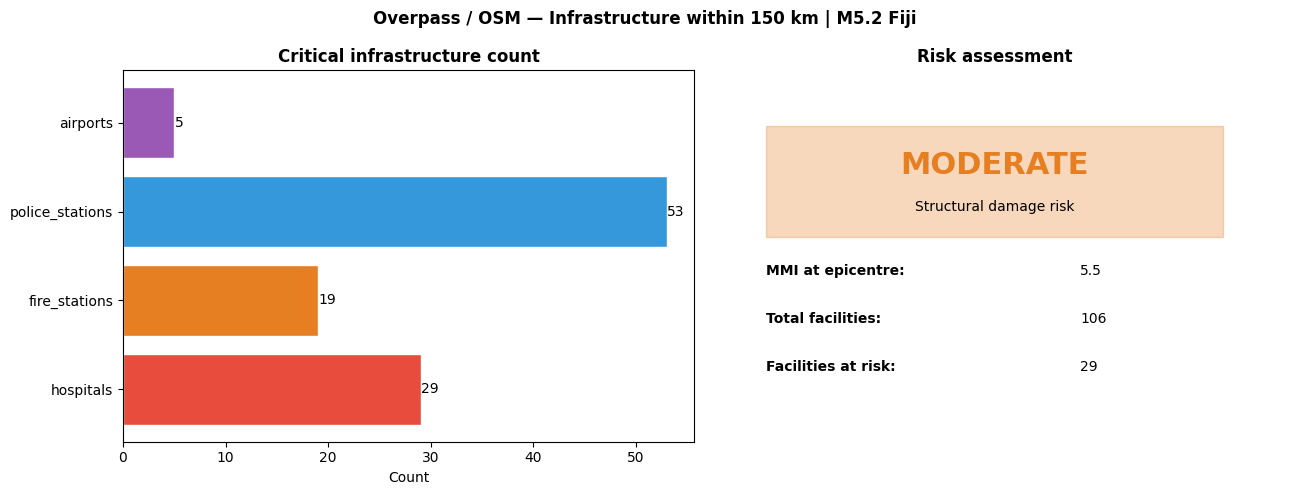

📊 Saved as nb4_overpass_result.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f"Overpass / OSM — Infrastructure within {RADIUS_M//1000} km | M{MAG} Fiji",
             fontsize=12, fontweight='bold')

# Bar chart of counts
ax = axes[0]
cat_labels = list(counts.keys())
cat_vals   = list(counts.values())
cat_colors = ['#e74c3c','#e67e22','#3498db','#9b59b6']
bars = ax.barh(cat_labels, cat_vals, color=cat_colors, edgecolor='white')
for bar, val in zip(bars, cat_vals):
    ax.text(bar.get_width()+0.05, bar.get_y()+bar.get_height()/2,
            str(val), va='center', fontsize=10)
ax.set_xlabel("Count")
ax.set_title("Critical infrastructure count", fontweight='bold')

# Risk summary
ax = axes[1]; ax.axis('off')
risk_color = {'LOW':'#2ecc71','MODERATE':'#e67e22','HIGH':'#e74c3c'}.get(risk,'#aaa')
ax.add_patch(plt.Rectangle((0.1,0.55),0.8,0.3, color=risk_color, alpha=0.3,
             transform=ax.transAxes, clip_on=False))
ax.text(0.5, 0.72, risk, ha='center', fontsize=22, fontweight='bold',
        color=risk_color, transform=ax.transAxes)
ax.text(0.5, 0.62, f"Structural damage risk", ha='center', fontsize=10,
        transform=ax.transAxes)
info = [("MMI at epicentre",f"{mmi}"),("Total facilities",str(total)),
        ("Facilities at risk",str(facilities_at_risk))]
for i,(l,v) in enumerate(info):
    y=0.45-i*0.13
    ax.text(0.1,y,f"{l}:",fontweight='bold',fontsize=10,transform=ax.transAxes)
    ax.text(0.65,y,v,fontsize=10,transform=ax.transAxes)
ax.set_title("Risk assessment", fontweight='bold')

plt.tight_layout()
plt.savefig("nb4_overpass_result.png", dpi=150, bbox_inches='tight')
plt.show()
print("📊 Saved as nb4_overpass_result.png")